In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
train_path = "/content/drive/MyDrive/data/maturity/train"
val_path = "/content/drive/MyDrive/data/maturity/val"
test_path = "/content/drive/MyDrive/data/maturity/test"

In [3]:
!pip install torch torchvision timm

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm

In [13]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [14]:
train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset = datasets.ImageFolder(val_path, transform=val_transform)
test_dataset = datasets.ImageFolder(test_path, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [16]:
model = timm.create_model('efficientnet_b0', pretrained=True)

# Freeze base layers
for param in model.parameters():
    param.requires_grad = False

# Modify classifier
model.classifier = nn.Sequential(
    nn.Linear(model.classifier.in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 2)
)

# Train classifier only
for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [19]:
epochs = 10

# 🔥 Unfreeze last block + classifier (fine-tuning)
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last EfficientNet block
for param in model.blocks[-1].parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in model.classifier.parameters():
    param.requires_grad = True

# Optimizer with lower LR
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.00001)

criterion = nn.CrossEntropyLoss()

for epoch in range(epochs):

    # 🔥 TRAIN
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # ✅ FIX: average loss
    avg_loss = train_loss / len(train_loader)

    # 🔥 VALIDATION
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = 100 * correct / total

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2f}%")

Epoch 1 | Loss: 0.0549 | Val Acc: 97.88%
Epoch 2 | Loss: 0.0394 | Val Acc: 98.59%
Epoch 3 | Loss: 0.0382 | Val Acc: 98.82%
Epoch 4 | Loss: 0.0391 | Val Acc: 98.59%
Epoch 5 | Loss: 0.0210 | Val Acc: 98.82%
Epoch 6 | Loss: 0.0243 | Val Acc: 99.29%
Epoch 7 | Loss: 0.0263 | Val Acc: 99.29%
Epoch 8 | Loss: 0.0382 | Val Acc: 98.82%
Epoch 9 | Loss: 0.0306 | Val Acc: 99.53%
Epoch 10 | Loss: 0.0228 | Val Acc: 99.29%


In [23]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 99.29%


In [29]:
def predict_ripeness(image_tensor):
    model.eval()

    with torch.no_grad():
        output = model(image_tensor.unsqueeze(0).to(device))
        probs = torch.nn.functional.softmax(output, dim=1)

        ripeness_percent = probs[0][1].item() * 100
        predicted_class = torch.argmax(probs, dim=1).item()

    classes = ['Immature', 'Mature']

    return ripeness_percent, classes[predicted_class]

In [30]:
import os
import random
from PIL import Image

# Path to test dataset
test_root = "/content/drive/MyDrive/data/maturity/test"

# Pick random class
random_class = random.choice(os.listdir(test_root))
class_path = os.path.join(test_root, random_class)

# Pick random image from that class
random_image_name = random.choice(os.listdir(class_path))
image_path = os.path.join(class_path, random_image_name)

# Load image
image = Image.open(image_path).convert("RGB")

print(f"Selected Class: {random_class}")
print(f"Image Path: {image_path}")

Selected Class: Mature Dragon Fruit
Image Path: /content/drive/MyDrive/data/maturity/test/Mature Dragon Fruit/Mature_Dragon_Original_Data0611.jpg


In [31]:
image_tensor = val_transform(image)

In [32]:
ripeness, stage = predict_ripeness(image_tensor)

print(f"Predicted Stage: {stage}")
print(f"Ripeness: {ripeness:.2f}%")

Predicted Stage: Mature
Ripeness: 99.87%


In [33]:
import random

def test_multiple_samples(n=5):
    for _ in range(n):
        random_class = random.choice(os.listdir(test_root))
        class_path = os.path.join(test_root, random_class)
        img_name = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, img_name)

        image = Image.open(img_path).convert("RGB")
        image_tensor = val_transform(image)

        ripeness, stage = predict_ripeness(image_tensor)

        print(f"Actual: {random_class} | Predicted: {stage} | {ripeness:.2f}%")

test_multiple_samples(5)

Actual: Mature Dragon Fruit | Predicted: Mature | 87.47%
Actual: Mature Dragon Fruit | Predicted: Mature | 99.97%
Actual: Mature Dragon Fruit | Predicted: Mature | 99.39%
Actual: Immature Dragon Fruit | Predicted: Immature | 0.56%
Actual: Mature Dragon Fruit | Predicted: Mature | 99.13%


In [35]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[248   0]
 [  3 174]]


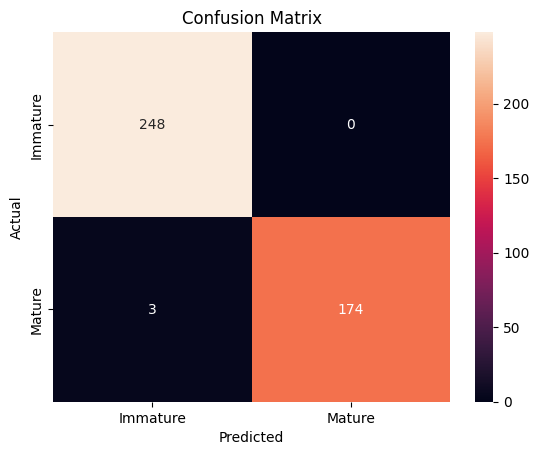

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Immature', 'Mature'],
            yticklabels=['Immature', 'Mature'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [37]:
class_names = train_dataset.classes

print(class_names)

['Immature Dragon Fruit', 'Mature Dragon Fruit']


In [38]:
torch.save(model.state_dict(), "/content/drive/MyDrive/ripeness_model.pth")

In [39]:
torch.save({
    'model_state_dict': model.state_dict(),
    'classes': train_dataset.classes
}, "/content/drive/MyDrive/ripeness_model_full.pth")